In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [8]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [9]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

Вывести несколько первых строк сгруппированных данных

In [10]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

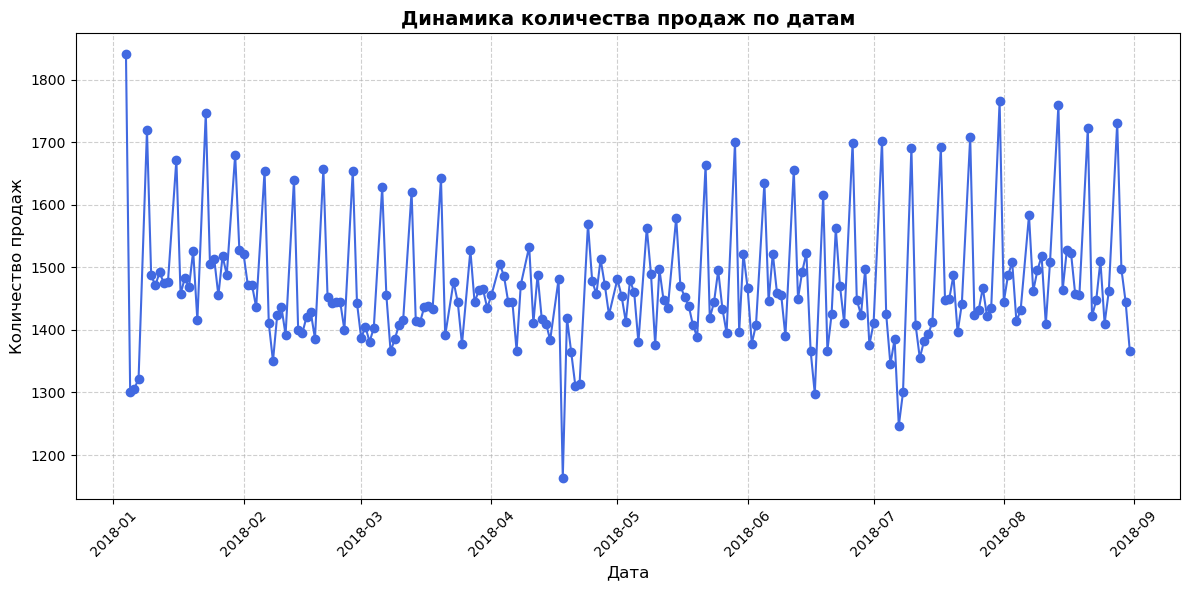

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'], marker='o', color='royalblue', linestyle='-')

plt.title('Динамика количества продаж по датам', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество продаж', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Динамика количества продаж по датам за период с января по сентябрь 2018 года.
 1. Общие характеристики и структура данныхОсь X (горизонтальная): 
Отображает временную шкалу (даты). Данные охватывают временной отрезок от 2018-01 (январь) до 2018-09 (сентябрь).
Подписи дат повернуты под углом 45 градусов.Ось Y (вертикальная): Отображает количественный показатель — «Количество продаж». 
Шкала начинается от 1200 и доходит до 1800+ единиц с шагом в 100 единиц.Тип графика: Линейный график (Line Plot) с точечными маркерами на каждый день,
что позволяет отслеживать ежедневные колебания.
2. Ключевые экстремумы (максимумы и минимумы)Абсолютный максимум: Самый высокий пик продаж зафиксирован в самом начале периода — 
в первой половине января 2018 года, когда продажи резко подскочили почти до 1850 единиц.
Локальные максимумы: На протяжении всего периода регулярно встречаются высокие пики, достигающие отметок в районе 1700–1750 единиц 
(например, в середине января, начале февраля, начале июня, а также в июле и августе).
Абсолютный минимум: Самый глубокий спад продаж произошел в середине апреля 2018 года — показатель упал ниже 1170 единиц.
Локальные минимумы: Также заметные сильные провалы в продажах (до уровня 1250 и ниже) наблюдаются в районе июля и начала января.
3. Закономерности и трендыЦикличность (Сезонность): На графике четко выражена краткосрочная циклическая (вероятно, недельная) зависимость.
Продажи совершают регулярные волнообразные колебания: резкий взлет вверх, затем резкое падение вниз, и этот цикл повторяется на протяжении 
каждого месяца. Это типично для розничной торговли или онлайн-сервисов, где спрос сильно привязан к выходным и будним дням.
    
Общий тренд: Выраженного долгосрочного тренда на постоянный рост или падение нет. Продажи колеблются в стабильном коридоре.
Поведение весной: Можно заметить, что в весенний период (март, апрель, май) общая амплитуда колебаний слегка затухает, 
и средний уровень продаж держится в более узком и чуть более низком коридоре (1350–1550 единиц), 
за исключением аномального падения в апреле. В летние же месяцы (июнь–август) разброс значений снова увеличивается, возвращаясь к пикам около 1700.   

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [13]:
# Считаем границы нормальных значений
Q1 = grouped_df['Количество продаж'].quantile(0.25)
Q3 = grouped_df['Количество продаж'].quantile(0.75)
IQR = Q3 - Q1

# Выбросами считается всё, что выходит за эти границы
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Отфильтруем строки, которые являются статистическими выбросами
outliers = grouped_df[(grouped_df['Количество продаж'] < lower_bound) | (grouped_df['Количество продаж'] > upper_bound)]
print("Все статистические выбросы в данных:")
print(outliers)


Все статистические выбросы в данных:
          Дата  Количество продаж
0   2018-01-04               1840
4   2018-01-09               1719
10  2018-01-16               1672
16  2018-01-23               1746
22  2018-01-30               1680
28  2018-02-06               1654
34  2018-02-13               1640
40  2018-02-20               1657
46  2018-02-27               1654
52  2018-03-06               1628
64  2018-03-20               1642
88  2018-04-18               1164
117 2018-05-22               1663
123 2018-05-29               1700
129 2018-06-05               1635
135 2018-06-12               1656
147 2018-06-26               1699
153 2018-07-03               1702
157 2018-07-07               1247
159 2018-07-10               1691
165 2018-07-17               1692
171 2018-07-24               1708
177 2018-07-31               1765
189 2018-08-14               1759
195 2018-08-21               1722
201 2018-08-28               1731


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [16]:
df['Дата'] = pd.to_datetime(df['Дата'])

summer_wednesdays_warehouse3 = df[
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2) & 
    (df['Склад'] == 3)
]


top_product = summer_wednesdays_warehouse3.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product = top_product.sort_values(by='Количество', ascending=False).iloc[0]

print("Топовый товар по продажам:")
print(top_product)


Топовый товар по продажам:
Номенклатура    product_1
Количество           2267
Name: 1, dtype: object


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

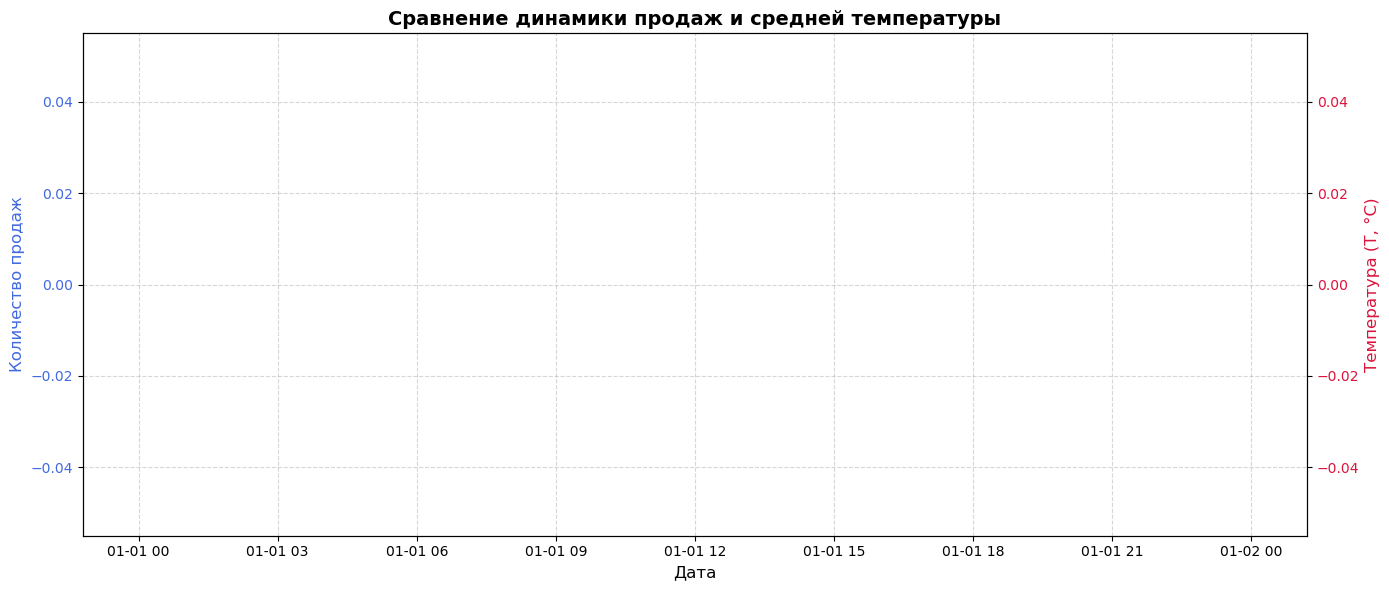

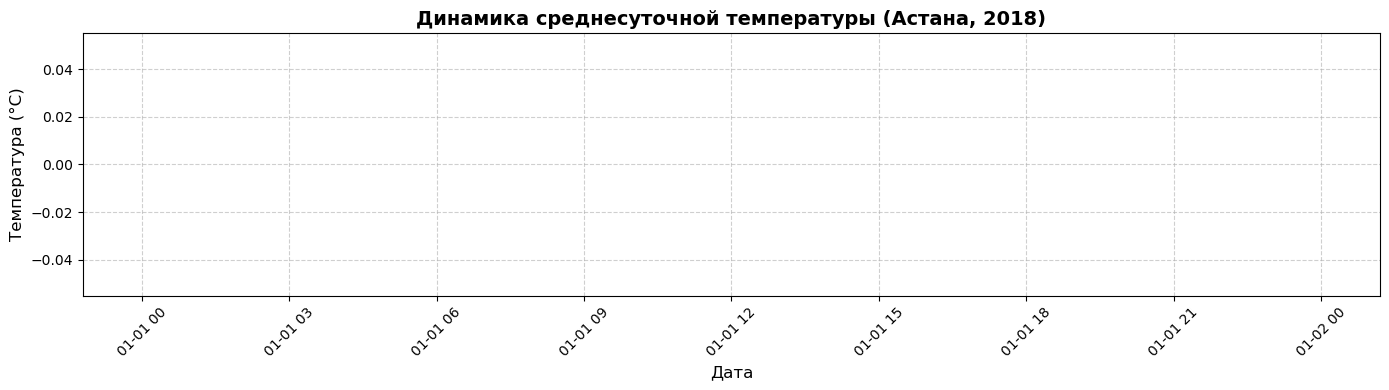

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Загружаем файл
weather_file = '35180.01.01.2018.31.12.2018.1.0.0.ru.ansi.00000000.csv.gz'
weather_df = pd.read_csv(weather_file, skiprows=6, sep=';', on_bad_lines='skip', encoding='cp1251')

# Автоматически определяем имена колонок времени и температуры
time_col = weather_df.columns[0]  # Первая колонка — это всегда дата/время
t_col = [col for col in weather_df.columns if col.strip() == 'T'][0]  # Находим чистую колонку 'T'

# 2. Приводим дату к формату datetime и выделяем чистый день
weather_df['Дата_время'] = pd.to_datetime(weather_df[time_col], dayfirst=True)
weather_df['Дата'] = weather_df['Дата_время'].dt.date

# 3. Группируем по дням и считаем СРЕДНЮЮ температуру за каждые сутки
weather_daily = weather_df.groupby('Дата')[t_col].mean().reset_index()
weather_daily.columns = ['Дата', 'T']
weather_daily['Дата'] = pd.to_datetime(weather_daily['Дата'])

# 4. Убедимся, что в продажах даты имеют тот же тип
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])

# 5. Объединяем продажи и погоду по столбцу 'Дата'
merged_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')

# --- ГРАФИК 1: Количество продаж и Температура ---
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'royalblue'
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Количество продаж', color=color, fontsize=12)
ax1.plot(merged_df['Дата'], merged_df['Количество продаж'], color=color, label='Продажи', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color = 'crimson'
ax2.set_ylabel('Температура (T, °C)', color=color, fontsize=12)
ax2.plot(merged_df['Дата'], merged_df['T'], color=color, label='Температура (T)', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Сравнение динамики продаж и средней температуры', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# --- ГРАФИК 2: Отдельный график температуры ---
plt.figure(figsize=(14, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='orangered', linewidth=2)
plt.title('Динамика среднесуточной температуры (Астана, 2018)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
